1. Build a simple prompt base chat - budha
2. Build a RAG (Single Shot)
3. Build it with agent loop and tool: search, read, askclarifyingquestion
4. Calculator or python executor, give it date and time of today.
5. Customizable tools : add tools as json file (MCPs)
7. Customizable system prompt - skill.md
8. Memory - search_memory, read_memory, write_memory, delete_memory tools
9. SubAgents
10. Background tasks and parallel tasks
11. 

In [2]:
from sklearn.datasets import fetch_openml

# Download MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("First label:", y[0])

X shape: (70000, 784)
y shape: (70000,)
First label: 5


In [3]:
import matplotlib.pyplot as plt

In [4]:
plt.show(X[0])

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [13]:
X[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [11]:
from pprint import pprint

pprint(X[0].reshape(28, 28))

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

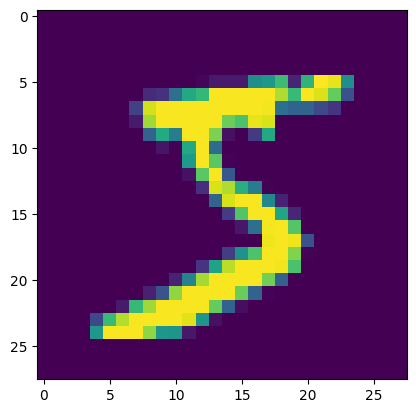

In [12]:
plt.imshow(X[0].reshape(28, 28))

In [14]:
y[0]

np.int64(5)

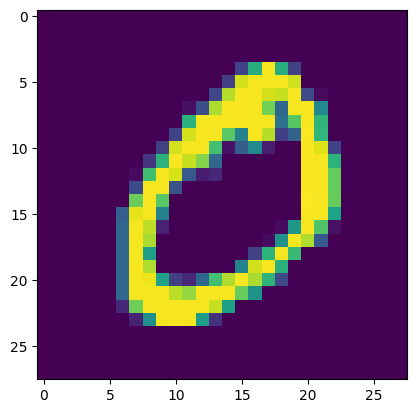

In [15]:
plt.imshow(X[1].reshape(28, 28))

In [16]:
y[1]

np.int64(0)

In [17]:
outer_area = 1
inner_area = (1 - 0.02) ** 2
material = outer_area - inner_area
material

0.03960000000000008

In [18]:
outer = 1
inner = (1 - 0.02) ** 3
material = outer - inner
material

0.05880800000000008

In [19]:
outer = 1
inner = (1 - 0.02) ** 4
material = outer - inner
material

0.07763184000000012

In [26]:
outer = 1
inner = (1 - 0.02) ** 200
material = outer - inner
material

0.9824120533942785

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(56000, 784) (56000,)
(14000, 784) (14000,)


In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=100,
            solver="lbfgs",
            n_jobs=-1
        )
    )
])


In [43]:
import numpy as np
yp = np.array([.9, .8, .1, 0.1])
yactual = np.array([1, 1, 0, 0])
mse = np.sum((yp - yactual)**2)
mse 

np.float64(0.06999999999999998)

In [44]:
import numpy as np
yp = np.array([.7, .7, .2, 0.2])
yactual = np.array([1, 1, 0, 0])
mse = np.sum((yp - yactual)**2)
mse 

np.float64(0.26000000000000006)

In [45]:
import numpy as np
yp = np.array([.9, .7, .5, 0.2])
yactual = np.array([1, 1, 0, 0])
mse = np.sum((yp - yactual)**2)
mse 

np.float64(0.39)

In [47]:
import numpy as np
yp = np.array([.9, .7, .5, 0.2])
yactual = np.array([1, 1, 0, 0])
lerror = -np.sum(np.log2(yp)*yactual + np.log2(1-yp)*(1-yactual))
lerror

np.float64(1.9885043611621707)

In [48]:
import numpy as np
yp = np.array([.9, .9, .5, 0.2])
yactual = np.array([1, 1, 0, 0])
lerror = -np.sum(np.log2(yp)*yactual + np.log2(1-yp)*(1-yactual))
lerror

np.float64(1.6259342817774622)

In [49]:
import numpy as np
yp = np.array([.9, .9, .3, 0.2])
yactual = np.array([1, 1, 0, 0])
lerror = -np.sum(np.log2(yp)*yactual + np.log2(1-yp)*(1-yactual))
lerror

np.float64(1.1405074546072207)

In [50]:
import numpy as np
yp = np.array([.9, .9, .1, 0.2])
yactual = np.array([1, 1, 0, 0])
lerror = -np.sum(np.log2(yp)*yactual + np.log2(1-yp)*(1-yactual))
lerror

np.float64(0.7779373752225122)

In [52]:
import numpy as np
yp = np.array([.9, .9, 0.00001, 0.2])
yactual = np.array([1, 1, 0, 0])
lerror = -np.sum(np.log2(yp)*yactual + np.log2(1-yp)*(1-yactual))
lerror

np.float64(0.6259487088000062)

In [53]:
import numpy as np
yp = np.array([.9, .9, 0.00001, 0.01])
yactual = np.array([1, 1, 0, 0])
lerror = -np.sum(np.log2(yp)*yactual + np.log2(1-yp)*(1-yactual))
lerror

np.float64(0.318520183607759)

In [55]:
import numpy as np
yp = np.array([.9, .9, 0.9, 0.9])
yactual = np.array([1, 1, 0, 0])
lerror = -np.sum(np.log2(yp)*yactual)
lerror

np.float64(0.3040061868900999)

In [ ]:
import numpy as np
yp = np.array([.9, .9, 0.9, 0.9])
yactual = np.array([1, 1, 0, 0])
lerror = -np.sum(np.log2(yp)*yactual)
lerror